In [15]:
import pandas as pd
from Bio import SeqIO
import sys
import os
from ast import literal_eval
import numpy as np


import pybedtools
from pybedtools import BedTool


#For plotting
from matplotlib.colors import LinearSegmentedColormap
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

#For statistics
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy import stats
from scipy.stats import gaussian_kde
from scipy.stats import pearsonr
from scipy.stats import spearmanr
import itertools

import re
from Bio import SeqIO
import ast # for safe eveal, for parsing some of the data
import math
os.chdir('/home/labs/davidgo/Collaboration/backup/MPRA_QC_pipeline/QC_analysis/scripts')

#import importlib
#importlib.reload(const)

import const #to reload use import(importlib) and then importlib.reload(const)
from const import MPRA_data_paths
from const import pos_active_ctrl_color,neg_active_ctrl_color,highlight_color,custom_cmap
from const import set_equal_plot_limits
from const import plot_color_pallete
from const import custom_cmap_bolder
from const import FONT_SIZE_small
const.set_plot_style()
import matplotlib.ticker as mtick

os.chdir('/home/labs/davidgo/Collaboration/backup/humanMPRA/scripts/produce_paper_figures')

output_path = '/home/labs/davidgo/Collaboration/humanMPRA/paper/raw_plots/'

# Parameters

In [16]:
# Use CPM normalization?
cpm=True

# Use log scale in visualization?
logScale=False

#Additional filters?
min_DNA_reads = 5 

min_DNA_counts = 0

# Figure 1 - hMPRA validation

### import and process all libraries

In [17]:
full_activity_df = pd.read_csv('/home/labs/davidgo/Collaboration/humanMPRA/chondrocytes/quantitative_analysis_combined/comb_df_combined_fdr.csv')


/tmp/ipykernel_2141644/3656142334.py:1: DtypeWarning: Columns (55) have mixed types. Specify dtype option on import or set low_memory=False.
  full_activity_df = pd.read_csv('/home/labs/davidgo/Collaboration/humanMPRA/chondrocytes/quantitative_analysis_combined/comb_df_combined_fdr.csv')


#### Apply filters

In [18]:
# Keep only rows where the 'oligo' column contains "SCREEN"
print(f"oligos before filtering for SCREEN overlap:{len(full_activity_df)}")
full_activity_df = full_activity_df[full_activity_df["oligo"].str.contains("SCREEN", na=False)]
print(f"oligos after filtering for SCREEN overlap:{len(full_activity_df)}")
full_activity_df =  full_activity_df[~full_activity_df["oligo"].str.contains("Ctrl", na=False)]
print(f"oligos after filtering for non-controls:{len(full_activity_df)}")

min_DNA_counts
if min_DNA_counts>0:
    full_activity_df =  full_activity_df[(full_activity_df['DNA_rep_comb']>min_DNA_counts)]
    print(f"oligos after filtering for oligos with over 10 DNA counts (combined for all replicates):{len(full_activity_df)}")



# remove oligos which were later removed
full_activity_df = full_activity_df[~(full_activity_df['orientation_fix']=='fixed_in_L4')&
                           ~(full_activity_df['oligo'].str.contains('SCREEN_EH'))&
                          ~(full_activity_df['oligo'].str.contains('hh.missing.oligos')) ]
print(f"oligos after filtering out oligos which were later remoed due to L4a1 (eg orientation fix):{len(full_activity_df)}")

#if min_barcodes>0:
#    full_activity_df =  full_activity_df[(full_activity_df['bcs_DNA_rep1']>10) &(full_activity_df['bcs_DNA_rep2']>10)]
#    print(f"oligos after filtering for oligos with over 10 barcodesin both reps 1 and 2:{len(full_activity_df)}")


oligos before filtering for SCREEN overlap:740391
oligos after filtering for SCREEN overlap:713347
oligos after filtering for non-controls:712588
oligos after filtering out oligos which were later remoed due to L4a1 (eg orientation fix):702647


In [19]:
# Add normalization of RNA and DNA counts
DNA_sum = full_activity_df["DNA_rep_comb"].sum()
RNA_sum = full_activity_df["RNA_rep_comb"].sum()

full_activity_df["DNA_rep_comb_cpm"] = 1000000*(full_activity_df["DNA_rep_comb"]+1)/DNA_sum
full_activity_df["RNA_rep_comb_cpm"] = 1000000*(full_activity_df["RNA_rep_comb"]+1)/RNA_sum

full_activity_df["DNA_rep_comb_cpm_log"] = np.log2(full_activity_df["DNA_rep_comb_cpm"])
full_activity_df["RNA_rep_comb_cpm_log"] = np.log2(full_activity_df["RNA_rep_comb_cpm"])


In [20]:
full_comparative_df = pd.read_csv("/home/labs/davidgo/Collaboration/humanMPRA/chondrocytes/comparative_analysis_combined/mpranalyze_comp_res_fdr_complete.csv")
full_comparative_df = full_comparative_df[['oligo','logFC','differntial.wo_controls']]
full_comparative_df = full_comparative_df.rename(
    columns={'differntial.wo_controls': 'differential_activity'}
)


## Drop shape

In [101]:
# Prepare the data
# Replace Inf values with NaN, then drop any rows with NaN values
replicates_activity_df = full_activity_df[['oligo','ratio_log_rep1','ratio_log_rep2','bcs_DNA_rep1','bcs_DNA_rep2']].copy()

print(f'Number of oligos: {len(replicates_activity_df)}')

replicates_activity_df.replace([np.inf, -np.inf], np.nan)

# Drop rows where either 'ratio_log_filtered_std2_rep1' or 'ratio_log_filtered_std2_rep2' has NaN or Inf
replicates_activity_df = replicates_activity_df.dropna(subset=['ratio_log_rep1', 'ratio_log_rep2'])

#replicates_activity_df = replicates_activity_df.sample(n=60000, random_state=42)

x = replicates_activity_df['ratio_log_rep1'].values
y = replicates_activity_df['ratio_log_rep2'].values


Number of oligos: 702647


<Figure size 800x800 with 0 Axes>

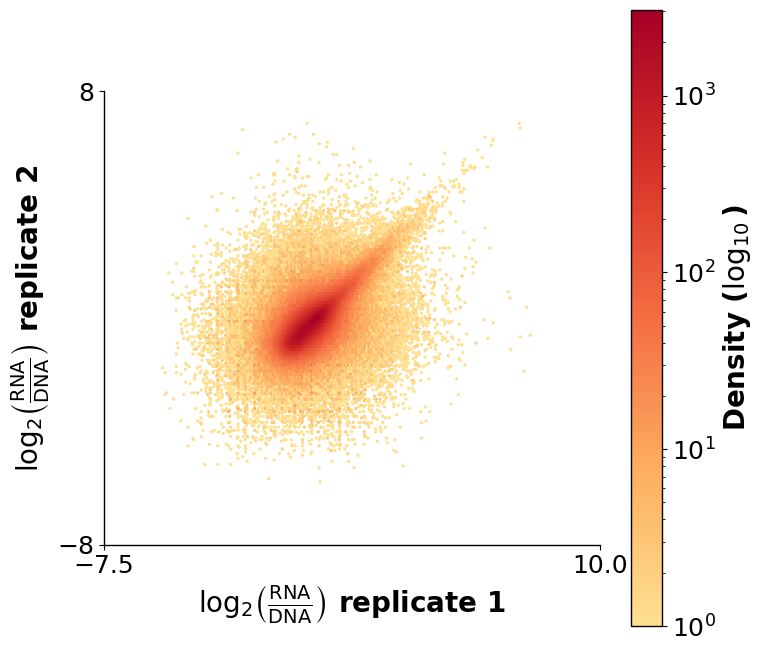

In [103]:
plt.clf()

fig, ax = plt.subplots()

hb = ax.hexbin(
    x, y,
    gridsize=200,          # adjust for coarser/finer grid
    cmap=custom_cmap_bolder,
    mincnt=1,             # only show hexes with at least 1 point
    bins='log'            # color ~ log(count); remove if you want raw counts
    # alpha=0.9           # optional, usually you can skip alpha for hexbin
)

# Add colorbar
cb = fig.colorbar(hb, ax=ax)
cb.set_label(r'Density ($\log_{10}$)')

ax.set_xlabel(r'$\log_{2}\!\left(\frac{\mathrm{RNA}}{\mathrm{DNA}}\right)$ replicate 1')
ax.set_ylabel(r'$\log_{2}\!\left(\frac{\mathrm{RNA}}{\mathrm{DNA}}\right)$ replicate 2')

# Keep your tick simplification
xticks = ax.get_xticks()
yticks = ax.get_yticks()
ax.set_xticks([xticks[0], xticks[-1]])
ax.set_yticks([yticks[0], yticks[-1]])

ax.set_aspect('equal', adjustable='box')
# Optional: set explicit limits if you want
# ax.set_xlim(-4, 6)
# ax.set_ylim(-4, 6)

const.save_fig(plt, 'RNA_DNA_ratio_correlation_between_replicates', output_path)
plt.show()


## Activity histogram

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


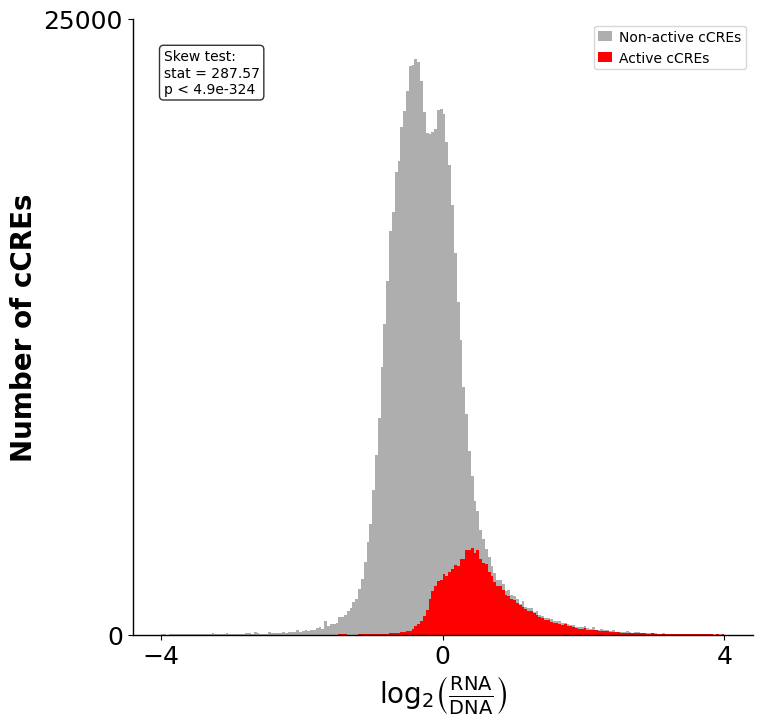

In [91]:
bin_edges = np.linspace(-4, 4, 201)  # 100 bins between -10 and 20

# First histogram (all scores)
plt.hist(
    data=full_activity_df,
    x='ratio_log_rep_comb', bins=bin_edges, color=plot_color_pallete['default_color'], label='Non-active cCREs')

# Second histogram (filtered scores)
plt.hist(
    data=full_activity_df[full_activity_df['activity_adjusted'] == 'active'],
    x='ratio_log_rep_comb', bins=bin_edges, color='red', label='Active cCREs')

plt.xlabel(r'$\log_{2}\!\left(\frac{\mathrm{RNA}}{\mathrm{DNA}}\right)$')
plt.ylabel('Number of cCREs')
plt.legend()
stat,pval=stats.skewtest(full_activity_df['ratio_log_rep_comb'].dropna())

# Smallest positive float in Python
min_p = np.nextafter(0, 1)  # ~5e-324 for float64

if pval < min_p:
    p_text = f"p < {min_p:.1e}"
else:
    p_text = f"p = {pval:.3g}"

plt.text(
    0.05, 0.95,  # relative position in axes coordinates
    f"Skew test:\nstat = {stat:.2f}\n{p_text}",
    ha='left', va='top',
    transform=plt.gca().transAxes,
    fontsize=10,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8)
)


plt.xticks([-4,0,4])

yticks = plt.gca().get_yticks()
plt.yticks([yticks[0], yticks[-1]])

plt.legend(
    loc="upper right",
    fontsize=10,         # smaller text
    markerscale=0.8,    # shrink the color boxes
    handlelength=1,     # shorter legend lines
    handletextpad=0.5,  # less padding between box and text
    borderpad=0.3       # tighter box
)


const.save_fig(plt,'activity_distribution',output_path)
plt.show()


##  Controls boxplot


In [22]:
# List of libraries
libraries = [
    "L1a1", "L1a2", "L1a3",
    "L2a1", "L2a2", "L2a3",
    "L3a1", "L3a2", "L3a3",
    "L4a1"
]

base_dir = r"/home/labs/davidgo/Collaboration/humanMPRA/chondrocytes"

dfs = []

for lib in libraries:
    csv_path = os.path.join(
        base_dir,
        lib,
        "output",
        "activity_after_filter",
        "comb_df_adjusted_fdr.csv"
    )

    # Read CSV
    df = pd.read_csv(csv_path)

    # Keep only rows where "oligo" contains "ctrl"
    df_ctrl = df[
    df["oligo"].str.contains("Ctrl", na=False, case=False) |
    df["oligo"].str.contains("scramble", na=False, case=False)
        ].copy()
    
    # Optional: add a column to remember which library it came from
    df_ctrl["library"] = lib

    dfs.append(df_ctrl)

# Combine all control oligos from all libraries into one df
all_ctrl_oligos = pd.concat(dfs, ignore_index=True)


In [23]:
control_types = [
    "NegCtrl_active_not_diff_ESCs+Osteoblasts+NPCs",
    "NegCtrl_non_SCREEN",
    "scrambled_control",
    "PosCtrl_diff_ESCs_Weiss_seq11687_derived_a1_L4",
    "NegCtrl_not_active_ESCs+Osteoblasts+NPCs",
    "PosCtrl_diff_ESCs+Osteoblasts+NPCs",
    "PosCtrl_chondrocyte_active",
    "PosCtrl_diff_NPCs_Weiss",
    "PosCtrl_diff_ESCs+NPCs",
    "PosCtrl_diff_ESCs_Weiss",
    "PosCtrl_diff_ESCs+Osteoblasts",
    "PosCtrl_diff_Osteoblasts+NPCs",
    "PosCtrl_diff_Osteoblasts",
    "PosCtrl_neuron_active",
    "PosCtrl_osteoblast_active",
]

ctrl_dict = {}

for ctype in control_types:
    mask = all_ctrl_oligos["oligo"].str.contains(ctype, regex=False)
    ctrl_dict[ctype] = all_ctrl_oligos[mask].copy()

# Optional: if you want a df of any remaining controls that didn't match:
unmatched_mask = ~pd.concat(
    [all_ctrl_oligos["oligo"].str.contains(ct, na=False, regex=False) for ct in control_types],
    axis=1
).any(axis=1)

ctrl_dict["other_ctrls"] = all_ctrl_oligos[unmatched_mask].copy()

to_combine = [
    "PosCtrl_chondrocyte_active",
    "PosCtrl_osteoblast_active",
    "NegCtrl_active_not_diff_ESCs+Osteoblasts+NPCs"
]

ctrl_dict["all_activity_pos_ctrl"] = (
    pd.concat([ctrl_dict[k] for k in to_combine], ignore_index=True)
)

#Add the tested cCREs
# Add tested cCREs as a new entry in the control dictionary
# (here we only keep mad.score since that's what we plot)
ctrl_dict["tested_cCREs"] = full_activity_df[["mad.score"]]



/tmp/ipykernel_2141644/416908.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


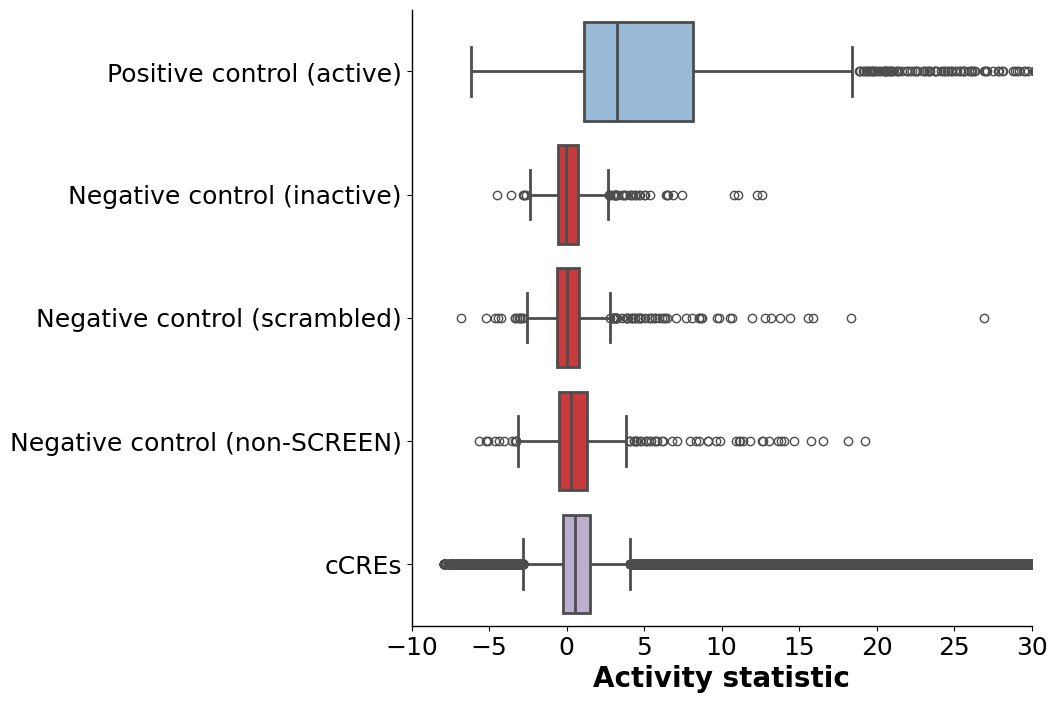

: 

In [ ]:
pos_color  = '#8FBCE1'
neg_color  = '#DE2326'
high_color = '#BBA9D2'

# Keys from the dictionary and their pretty labels
plot_keys = {
    "scrambled_control": "Negative control (scrambled)",
    "NegCtrl_non_SCREEN": "Negative control (non-SCREEN)",
    "all_activity_pos_ctrl": "Positive control (active)",
    "NegCtrl_not_active_ESCs+Osteoblasts+NPCs": "Negative control (inactive)",
    "tested_cCREs": "cCREs",
}

plot_dfs = []
for key, pretty in plot_keys.items():
    if key not in ctrl_dict:
        continue
    df_temp = ctrl_dict[key].copy()
    df_temp["control_type"] = key
    df_temp["control_type_pretty"] = pretty
    plot_dfs.append(df_temp)

c = pd.concat(plot_dfs, ignore_index=True)

# Order of boxplots (y-axis)
order = [
    "Positive control (active)",
    "Negative control (inactive)",
    "Negative control (scrambled)",
    "Negative control (non-SCREEN)",
    "cCREs",
]

# Matching colors
palette = [
    pos_color,  # Positive control (active)
    neg_color,  # Negative control (inactive)
    neg_color,  # Negative control (scrambled)
    neg_color,  # Negative control (non-SCREEN)
    high_color, # cCREs
]
sns.boxplot(
    data=c,
    x="mad.score",
    y="control_type_pretty",
    showfliers=True,
    linewidth=2,
    order=order,
    palette=palette
)
plt.xlim(-10,30)

plt.ylabel("")
plt.xlabel("Activity statistic")
plt.show()

/tmp/ipykernel_1232298/427876534.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


Text(0.5, 0, 'Activity statistic')

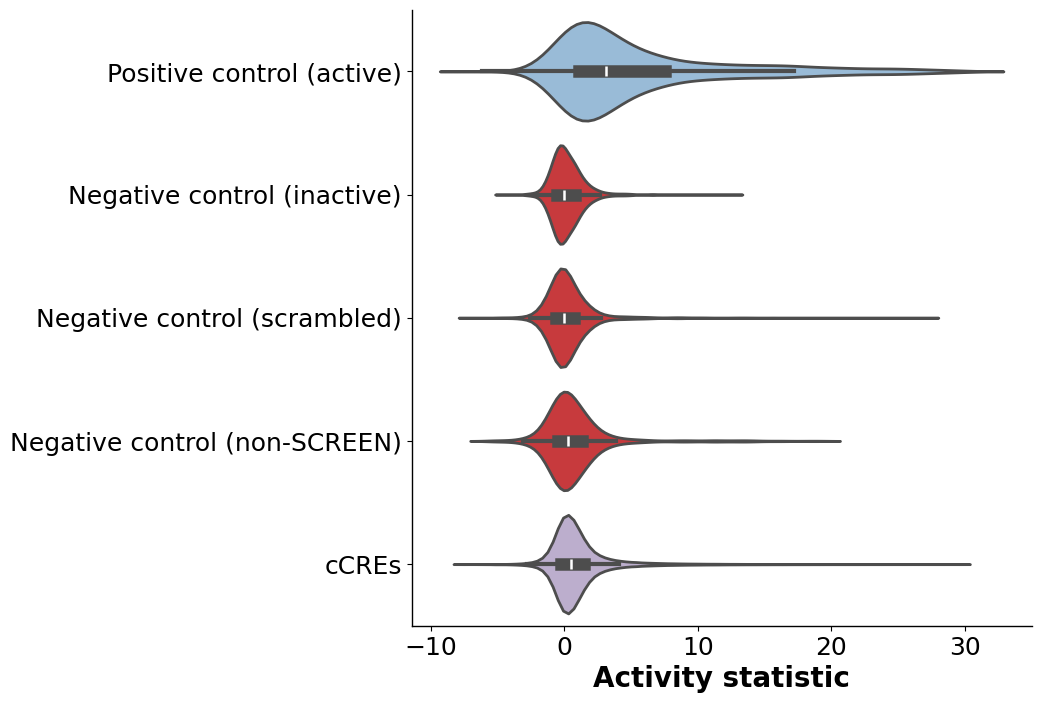

In [107]:
c_capped = c[c['mad.score']<30]
sns.violinplot(
    data=c_capped,
    x="mad.score",
    y="control_type_pretty",
    #showfliers=False,
    linewidth=2,
    order=order,
    palette=palette
)
plt.ylabel("")
plt.xlabel("Activity statistic")

## RNA vs DNA

In [108]:
# Prepare the data
x = full_activity_df['DNA_rep_comb'].values
y = full_activity_df['RNA_rep_comb'].values

# Build a mask removing NaN and ±inf in both x and y
mask = (
    np.isfinite(x) &
    np.isfinite(y) &
    (y < 300_000)
)

# Apply mask
x = x[mask]
y = y[mask]

print(len(x), "points remain after filtering.")


# Evaluate the KDE on the grid
#values = np.vstack([x, y])
#kernel = gaussian_kde(values)
#density = kernel(values)

701782 points remain after filtering.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


<Figure size 800x800 with 0 Axes>

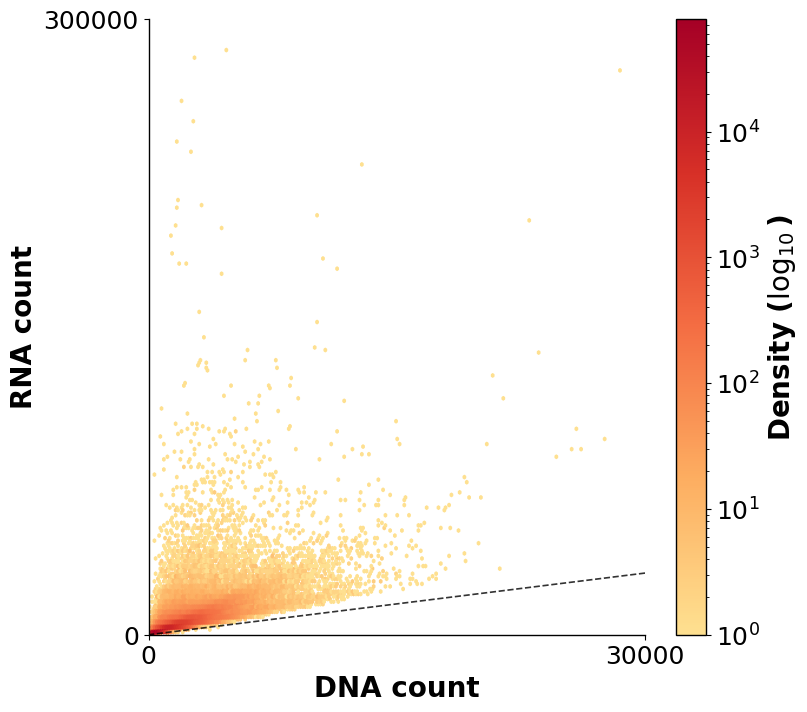

In [109]:
plt.clf()
fig, ax = plt.subplots()

# Hexbin density plot instead of scatter
hb = ax.hexbin(
    x, y,
    gridsize=200,              # tweak for smoother/coarser bins
    cmap=custom_cmap_bolder,  # same colormap as before
    mincnt=1,                 # only show bins with at least 1 point
    bins='log'                # log10 of counts
)

# Y = X diagonal
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

diag_min = min(xmin, ymin)
diag_max = max(xmax, ymax)

ax.plot(
    [diag_min, diag_max],
    [diag_min, diag_max],
    color='black',
    linestyle='--',
    linewidth=1.2,
    alpha=0.8
)

# Colorbar with label
cb = fig.colorbar(hb, ax=ax)
cb.set_label(r'Density ($\log_{10}$)')

# Set axis limits
ax.set_xlim(0, max(x))
ax.set_ylim(0, max(y))

# Simplify ticks (first & last)
xticks = ax.get_xticks()
yticks = ax.get_yticks()
ax.set_xticks([xticks[0], xticks[-1]])
ax.set_yticks([yticks[0], yticks[-1]])

# Axis labels
ax.set_xlabel('DNA count')
ax.set_ylabel('RNA count')

const.save_fig(plt, 'RNA_DNA_ratio', output_path)
plt.show()


## ancestral vs derived alleles

In [ ]:
ancestral_derived_data = full_activity_df.copy()
print(len(ancestral_derived_data))
ancestral_derived_data = ancestral_derived_data[ancestral_derived_data['count_rep_comb']>10]
#ancestral_derived_data = ancestral_derived_data[ancestral_derived_data['activity_adjusted_combined']=='active']
print(len(ancestral_derived_data))

# 1. Keep only rows that are ancestral/derived
ancestral_derived_data = ancestral_derived_data[ancestral_derived_data["oligo"].str.contains("ancestral|derived", case=False, na=False)].copy()


# 2. Add a column indicating whether it's ancestral or derived
ancestral_derived_data["status"] = np.where(
    ancestral_derived_data["oligo"].str.contains("ancestral", case=False, na=False),
    "ancestral",
    "derived"
)

# 3. Define a "pair_id" by removing the ancestral/derived part from the oligo name
def make_pair_id(s):
    # remove '_ancestral', '-ancestral', ' ancestral', etc. (same for derived)
    s = re.sub(r"[_\- ]?(ancestral|derived)", "", s, flags=re.IGNORECASE)
    return s

ancestral_derived_data["pair_id"] = ancestral_derived_data["oligo"].apply(make_pair_id)


# 4. Pivot so each row = one pair, with ancestral / derived mad.score as columns
ancestral_derived_data = (
    ancestral_derived_data
    .pivot_table(
        index="pair_id",
        columns="status",
        values="mad.score",
        aggfunc="first"   # in case there are duplicates
    )
    .reset_index()
)

#4. Merge with differential activity df 
ancestral_derived_data = ancestral_derived_data.merge(
    full_comparative_df,
    how='left',
    left_on='pair_id',
    right_on='oligo'
)

# Columns are now: ['pair_id', 'ancestral', 'derived']
# 5. Filter to keep only pairs where both values are real numbers (no NaN/inf)
mask_valid = (
    ancestral_derived_data["ancestral"].notna() &
    ancestral_derived_data["derived"].notna() &
    np.isfinite(ancestral_derived_data["ancestral"]) &
    np.isfinite(ancestral_derived_data["derived"])
)

ancestral_derived_data = ancestral_derived_data.dropna()

# Remove +inf or -inf
ancestral_derived_data = ancestral_derived_data[~ancestral_derived_data.isin([np.inf, -np.inf]).any(axis=1)]
#ancestral_derived_data = ancestral_derived_data.sample(n=100000, random_state=42)

In [ ]:
x = ancestral_derived_data['ancestral'].values
y = ancestral_derived_data['derived'].values
colors = ancestral_derived_data['differential_activity'].values

# Create the KDE (Kernel Density Estimate)
#values = np.vstack([x, y])
#kernel = gaussian_kde(values)

# Evaluate the KDE for each data point
#density = kernel(values)

#max_density_threshold = 0.1 

# Density maximum value clipping 
#density_capped = np.clip(density, a_min=None, a_max=max_density_threshold)

In [ ]:
plt.clf()

scatter = plt.scatter(
    x, y,
    #c=colors,               # color by differential.wo_controls
    alpha=0.1,
    s=10,
    edgecolors='none'
)

scatter = plt.scatter(
    x[colors==True], y[colors==True],
    c='red',               # color by differential.wo_controls
    s=10,
    edgecolors='none'
)


#plt.colorbar(scatter, label="Differential (wo controls)")

plt.xlabel(r'Ancestral allele mad score')
plt.ylabel(r'Derived allele mad score')

plt.xlim(0, 100)
plt.ylim(0,100)
xticks = plt.xticks()[0]
yticks = plt.yticks()[0]
plt.xticks([xticks[0], xticks[-1]])
plt.yticks([yticks[0], yticks[-1]])

const.save_fig(plt, 'RNA_DNA_ratio_correlation_between_replicates', output_path)
plt.show()


## Overlap with endogenous signal

### Load annotations

In [7]:

annotations = pd.read_csv(f'/home/labs/davidgo/Collaboration/humanMPRA/top_candidates/chondrocytes/humanMPRA_annotations_v3.csv', 
                     header=0)
annotations = annotations.drop_duplicates(subset=["oligo"], keep = "first") #There are several HH oligos which are duplicated
annotations = annotations[#~(annotations['orientation_fix']=='fixed_in_L4')&
                           ~(annotations['oligo'].str.contains('SCREEN_EH'))&
                          ~(annotations['oligo'].str.contains('hh.missing.oligos')) ]


# create BED of annotations
annotations_bed_df = annotations[["chromosome","start","end","oligo"]]
annotations_bed_df.loc[:,"start"] = annotations_bed_df["start"].map(int) # already zero-based - Make sure with Simon!!
annotations_bed_df.loc[:,"end"] = annotations_bed_df["end"].map(int)
annotations_bed_df=annotations_bed_df.sort_values(['chromosome','start'], ascending = [True, True])
annotations_bed = pybedtools.BedTool.from_dataframe(annotations_bed_df)

/tmp/ipykernel_2141644/839179135.py:1: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  annotations = pd.read_csv(f'/home/labs/davidgo/Collaboration/humanMPRA/top_candidates/chondrocytes/humanMPRA_annotations_v3.csv',


#### Double check that there are equal number of cCREs in annoatations and the original activity df

In [8]:
def remove_derivation(s):
    # remove "_derived_*" OR "_ancestral_*"
    return re.sub(r'_derived[^_]*', '', re.sub(r'_ancestral[^_]*', '', s))

full_norm = full_activity_df["oligo"].apply(remove_derivation)
ann_norm  = annotations["oligo"].apply(remove_derivation)
set_full = set(full_norm)
set_ann  = set(ann_norm)

missing_in_annotations = set_full - set_ann
missing_in_full = set_ann - set_full

df_missing_in_annotations = full_activity_df[full_norm.isin(missing_in_annotations)]
df_missing_in_full        = annotations[ann_norm.isin(missing_in_full)]

print("len(full_activity_df) =", len(full_activity_df))
print("len(annotations)      =", len(annotations))

print("unique normalized in full =", len(set_full))
print("unique normalized in ann  =", len(set_ann))
print("sets equal?               =", set_full == set_ann)


len(full_activity_df) = 702647
len(annotations)      = 355891
unique normalized in full = 355891
unique normalized in ann  = 355891
sets equal?               = True


## Load SCREEN database for annotation

In [11]:
screen_version='V2'

screen_file_hg19 = '/home/labs/davidgo/Collaboration/USEFUL_DATASETS/Chromatin/ENCODE SCREEN/' + screen_version + '/GRCh37-lifted-cCREs.bed'
screen_annotation_file='/home/labs/davidgo/Collaboration/USEFUL_DATASETS/Chromatin/ENCODE SCREEN/' + screen_version + '/GRCh38-cCREs.bed'

# the annotations were truncated in the liftover, need to join with the hg38 file
screen_hg19_df=pd.read_csv(screen_file_hg19, sep='\t',header=None)
screen_annotation_df=pd.read_csv(screen_annotation_file, sep='\t',header=None)
screen_annotation_df.drop(columns=[0,1,2,3], inplace=True)
print(len(screen_hg19_df))
screen_df = pd.merge(screen_hg19_df,screen_annotation_df,left_on=4,right_on=4,how='left')
print(len(screen_df))

screen_df.drop(columns=['5_x'], inplace=True)
screen_df.rename(columns={"5_y": "regulatoryClass"},inplace=True)
screen_df["regulatoryClass"] = screen_df["regulatoryClass"].str.replace(',CTCF-bound','')
screen_df.drop(screen_df[screen_df.regulatoryClass =='CTCF-only'].index, inplace=True)
screen_df.drop(columns = (3),inplace=True)
screen_df.rename(columns = {4:'enhancerID'},inplace=True)


screen_df = screen_df.sort_values([0,1], ascending = [True, True])
screen_bed=pybedtools.BedTool.from_dataframe(screen_df)

924834
924834


In [35]:

merged_screen_bed = screen_bed.merge()

# Intersect with annotations
intersect_bed = annotations_bed.intersect(merged_screen_bed, wao=True)
intersect_df = intersect_bed.to_dataframe()
intersect_df.drop(['score','strand','thickStart'], axis=1,inplace=True)

print('#overlpas with SCREEN elements:', len(intersect_df))

# Thickend represents the #BP overlap between each oligo and a SCREEN element
intersect_df = (intersect_df.groupby([col for col in intersect_df.columns if col != 'thickEnd'], as_index=False)
      .agg({'thickEnd': 'sum'})
)

print('# overlaps after collpasing per oligo :', len(intersect_df))

oligos_SCREEN = pd.merge(annotations, intersect_df[['thickEnd', 'name']], left_on='oligo', right_on = "name", how='left')
oligos_SCREEN.drop("name", axis=1,inplace=True)
   

#overlpas with SCREEN elements: 406171
# overlaps after collpasing per oligo : 355891


In [ ]:
# grab classes per oligo
classes_df = annotations_bed.intersect(screen_bed, wao=True).to_dataframe()
classes_df = classes_df[['name', 'itemRgb']]
classes_df = classes_df.groupby('name', as_index=False).agg({'itemRgb': list})
classes_df.rename(columns={'itemRgb': 'CRE_class'}, inplace=True)


# join with main
oligos_class = pd.merge(annotations, classes_df[['CRE_class', 'name']], left_on='oligo', right_on = "name", how='left')
oligos_class.drop(columns = ["name"],inplace=True)
oligos_class['CRE_class'] = oligos_class['CRE_class'].apply(lambda x: ', '.join(map(str, x)))


oligos_class['SCREEN2_class_strict'] = (
    oligos_class['CRE_class']
    .apply(lambda x: ', '.join(map(str, x)) if isinstance(x, list) else x)  # Convert list to string if needed
    .apply(lambda x: set(x.split(', ')) if isinstance(x, str) else set())  # Convert to set for uniqueness
    .apply(lambda x: next(iter(x)) if len(x) == 1 else 'more than one')    # Extract single value or mark as "more than one"
)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


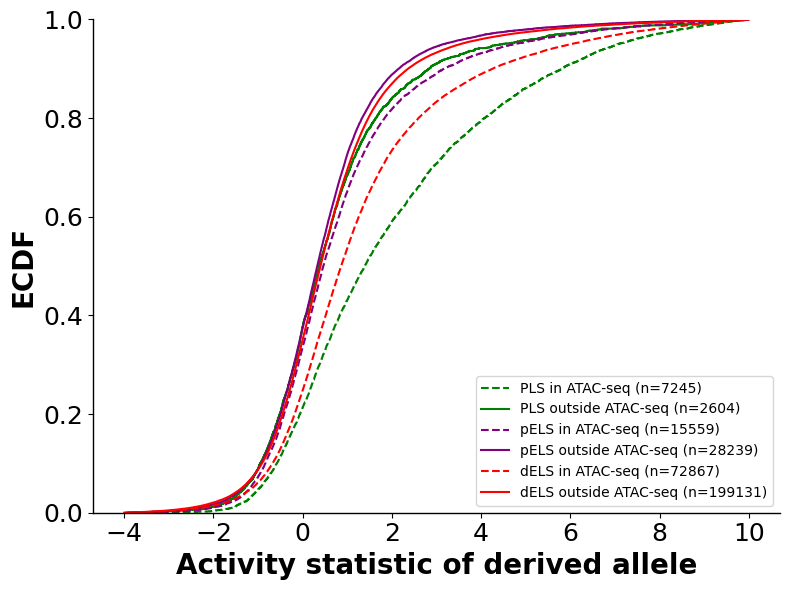


### Kolmogorov–Smirnov Tests Between All Pairs ###

dELS in ATAC-seq  vs  dELS outside ATAC-seq:  D = 0.1594,  p = 4.941e-324
dELS in ATAC-seq  vs  Other:  D = 0.1442,  p = 2.144e-226
dELS in ATAC-seq  vs  pELS outside ATAC-seq:  D = 0.1911,  p = 4.941e-324
dELS in ATAC-seq  vs  pELS in ATAC-seq:  D = 0.1182,  p = 1.936e-156
dELS in ATAC-seq  vs  PLS outside ATAC-seq:  D = 0.1530,  p = 7.714e-52
dELS in ATAC-seq  vs  PLS in ATAC-seq:  D = 0.1467,  p = 3.305e-124
dELS outside ATAC-seq  vs  Other:  D = 0.0297,  p = 4.189e-11
dELS outside ATAC-seq  vs  pELS outside ATAC-seq:  D = 0.0321,  p = 1.510e-22
dELS outside ATAC-seq  vs  pELS in ATAC-seq:  D = 0.0540,  p = 5.806e-37
dELS outside ATAC-seq  vs  PLS outside ATAC-seq:  D = 0.0332,  p = 6.722e-03
dELS outside ATAC-seq  vs  PLS in ATAC-seq:  D = 0.2885,  p = 4.941e-324
Other  vs  pELS outside ATAC-seq:  D = 0.0538,  p = 4.135e-25
Other  vs  pELS in ATAC-seq:  D = 0.0324,  p = 2.116e-07
Other  vs  PLS outside ATAC-seq:  D = 0.0166,  p =

In [13]:
# Ensure flag exists
oligos_class.loc[:, "in_ATAC-seq_peak"] = (oligos_class["ATACseq_peaks_fetal_chondrocytes"].abs() < 1)

# Create combined category: pELS / dELS / PLS × in/out of ATAC-seq
oligos_class["category"] = np.select(
    [
        (oligos_class["SCREEN2_class_strict"] == "pELS") & (oligos_class["in_ATAC-seq_peak"]),
        (oligos_class["SCREEN2_class_strict"] == "dELS") & (oligos_class["in_ATAC-seq_peak"]),
        (oligos_class["SCREEN2_class_strict"] == "PLS") & (oligos_class["in_ATAC-seq_peak"]),
        (oligos_class["SCREEN2_class_strict"] == "pELS") & (~oligos_class["in_ATAC-seq_peak"]),
        (oligos_class["SCREEN2_class_strict"] == "dELS") & (~oligos_class["in_ATAC-seq_peak"]),
        (oligos_class["SCREEN2_class_strict"] == "PLS") & (~oligos_class["in_ATAC-seq_peak"]),
    ],
    [
        "pELS in ATAC-seq",
        "dELS in ATAC-seq",
        "PLS in ATAC-seq",
        "pELS outside ATAC-seq",
        "dELS outside ATAC-seq",
        "PLS outside ATAC-seq",
    ],
    default="Other"
)

# Filter x-range
to_plot = oligos_class.loc[oligos_class["normalized_activity_estimate_derived"].between(-4, 10)].copy()

# Define colors and styles
color_map = {
    "PLS": "green",
    "pELS": "purple",
    "dELS": "red"
}
style_map = {
    True: "--",   # in ATAC-seq
    False: "-"    # outside ATAC-seq
}

plt.figure(figsize=(8, 6))

for cls in ["PLS", "pELS", "dELS"]:
    for in_peak in [True, False]:
        subset = to_plot[
            (to_plot["SCREEN2_class_strict"] == cls) &
            (to_plot["in_ATAC-seq_peak"] == in_peak)
        ].dropna(subset=["normalized_activity_estimate_derived"])
        if subset.empty:
            continue
        sns.ecdfplot(
            data=subset,
            x="normalized_activity_estimate_derived",
            stat="proportion",
            color=color_map[cls],
            linestyle=style_map[in_peak],
            label=f"{cls} {'in' if in_peak else 'outside'} ATAC-seq (n={len(subset)})"
        )

plt.xlabel("Activity statistic of derived allele")
plt.ylabel("ECDF")
plt.legend(fontsize=10)
plt.tight_layout()

const.save_fig(plt, 'derived_activity_by_ATAC_and_SCREEN2_strict_styled', output_path)
plt.show()

# ---- Kolmogorov–Smirnov tests between all pairs ----
print("\n### Kolmogorov–Smirnov Tests Between All Pairs ###\n")

# Collect all group distributions
group_values = {}
for cat in to_plot["category"].unique():
    vals = to_plot.loc[to_plot["category"] == cat, "normalized_activity_estimate_derived"].dropna().to_numpy()
    if vals.size > 0:
        group_values[cat] = vals

# Compute pairwise KS tests
for (name1, vals1), (name2, vals2) in itertools.combinations(group_values.items(), 2):
    if len(vals1) == 0 or len(vals2) == 0:
        continue
    ks = stats.ks_2samp(vals1, vals2)
    p_raw = float(ks.pvalue)
    p_report = p_raw if p_raw > 0 else np.nextafter(0, 1)
    print(f"{name1}  vs  {name2}:  D = {ks.statistic:.4f},  p = {p_report:.3e}")
    
# 1. Pooled ATAC-seq vs. outside ATAC-seq
vals_in_atac = to_plot.loc[to_plot["in_ATAC-seq_peak"], "normalized_activity_estimate_derived"].dropna()
vals_out_atac = to_plot.loc[~to_plot["in_ATAC-seq_peak"], "normalized_activity_estimate_derived"].dropna()
if len(vals_in_atac) and len(vals_out_atac):
    ks = stats.ks_2samp(vals_in_atac, vals_out_atac)
    print(f"Pooled ATAC-seq vs outside ATAC-seq:  D = {ks.statistic:.4f},  p = {ks.pvalue:.3e}")

    
# 2. Pooled enhancers (pELS + dELS) vs promoters (PLS)
vals_enhancers = to_plot.loc[to_plot["SCREEN2_class_strict"].isin(["pELS", "dELS"]),
                             "normalized_activity_estimate_derived"].dropna()
vals_promoters = to_plot.loc[to_plot["SCREEN2_class_strict"] == "PLS",
                             "normalized_activity_estimate_derived"].dropna()
if len(vals_enhancers) and len(vals_promoters):
    ks = stats.ks_2samp(vals_enhancers, vals_promoters)
    print(f"Pooled enhancers (pELS + dELS) vs promoters (PLS):  D = {ks.statistic:.4f},  p = {ks.pvalue:.3e}")

# 3. Pooled proximal vs distal enhancers
vals_proximal = to_plot.loc[to_plot["SCREEN2_class_strict"] == "pELS",
                            "normalized_activity_estimate_derived"].dropna()
vals_distal = to_plot.loc[to_plot["SCREEN2_class_strict"] == "dELS",
                          "normalized_activity_estimate_derived"].dropna()
if len(vals_proximal) and len(vals_distal):
    ks = stats.ks_2samp(vals_proximal, vals_distal)
    print(f"Pooled proximal (pELS) vs distal (dELS) enhancers:  D = {ks.statistic:.4f},  p = {ks.pvalue:.3e}")

